# 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importación de datasets 

In [2]:
from pathlib import Path

base_dir = 'kdd_datasets - tratados'


def load_all_datasets(base_dir: str = 'kdd_datasets - tratados') -> dict[str, pd.DataFrame]:
    """Carga todos los CSV del directorio y devuelve un diccionario de DataFrames."""
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f'Directorio no encontrado: {base_path}')

    datasets = {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(base_path.glob('*.csv'))
    }
    return datasets


datasets = load_all_datasets(base_dir)

# Asignar variables opcionales para uso directo
for name in [
    'condiciones_climaticas',
    'imagenes_metadata',
    'noticias_agricolas',
    'politicas_agricolas',
    'precios_mercado',
    'produccion_agricola',
    'produccion_ganadera',
    'reportes_plagas',
]:
    globals()[name] = datasets[name]

# Mostrar los tamaños de cada dataset
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


condiciones_climaticas: (256, 13)
imagenes_metadata: (250, 15)
noticias_agricolas: (60, 9)
politicas_agricolas: (148, 13)
precios_mercado: (864, 9)
produccion_agricola: (1200, 11)
produccion_ganadera: (600, 9)
reportes_plagas: (100, 11)


In [3]:
datasets['condiciones_climaticas'].head()

,codigo_iso,pais,regiones_anio,regiones_dias_con_heladas,regiones_eventos_extremos,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_nombre,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_minima,regiones_temperatura_promedio
0,ARG,Argentina,2017,62,NaN,40,24.06,4,Cuyo,1074,22.5,"0,5",12.4
1,ARG,Argentina,2015,4,NaN,70,19.09,2,Cuyo,873,20.8,"0,9",12.7
2,ARG,Argentina,2019,111,NaN,64,16.19,1,Cuyo,880,29.9,"4,8",15.1
3,ARG,Argentina,2018,64,NaN,68,12.85,0,Cuyo,907,30.6,"6,6",19.6
4,ARG,Argentina,2016,93,NaN,83,29.64,0,Cuyo,1387,22.6,"7,2",13.0


In [4]:
datasets['imagenes_metadata'].head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


# 3. Análisis exploratorio por tipo de datos
### 3.1 ¿Cómo se relaciona el uso de fertilizantes con el rendimiento?

In [20]:
fertilizante_rendimiento = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'fertilizantes_kg_ha', 'rendimiento_ton_ha']
].dropna()

fertilizante_rendimiento.head()

,pais,region,cultivo,anio,fertilizantes_kg_ha,rendimiento_ton_ha
0,Argentina,América del Sur,Soja,2011,105,2.22
1,Argentina,América del Sur,Maíz,2011,164,8.45
2,Argentina,América del Sur,Cebada,2011,105,2.77
3,Argentina,América del Sur,Té,2011,236,3.07
4,Argentina,América del Sur,Algodón,2011,276,1.18


In [19]:
fertilizante_rendimiento.isna().sum()

pais                   0
region                 0
cultivo                0
anio                   0
fertilizantes_kg_ha    0
rendimiento_ton_ha     0
dtype: int64

Al hacer el gráfico de correlación entre fertilizante y rendimiento se puede comprobar como no existe casi ninguna correlación entre ambos. Esto quiere decir que los cambios en las cantidades de fertilizantes usados no parecen tener ningún efecto en el crecimiento de los cultivos

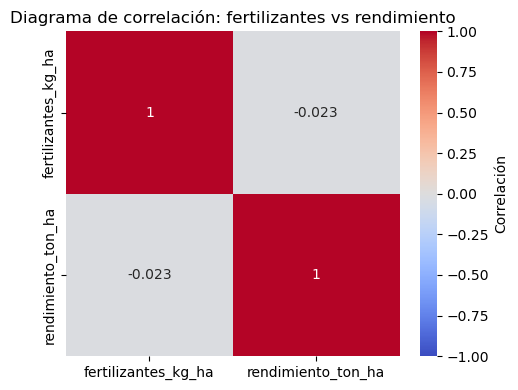

In [13]:
corr_matrix = fertilizante_rendimiento[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Diagrama de correlación: fertilizantes vs rendimiento')
plt.tight_layout()
plt.show()

En el caso del scatterplot donde se muestra la relación previa teniendo en cuenta los distintos cultivos, se puede ver que el rendimiento de la caña de azucar excede por bastante al resto de cultivos, que parecen tener un rendimiento casi nulo. Esto podría ser porque el uso de fertilizantes si que ayuda y aporta al crecimiento de la caña, mientras que al resto no les mejora tanto y por eso la relación previa es baja.

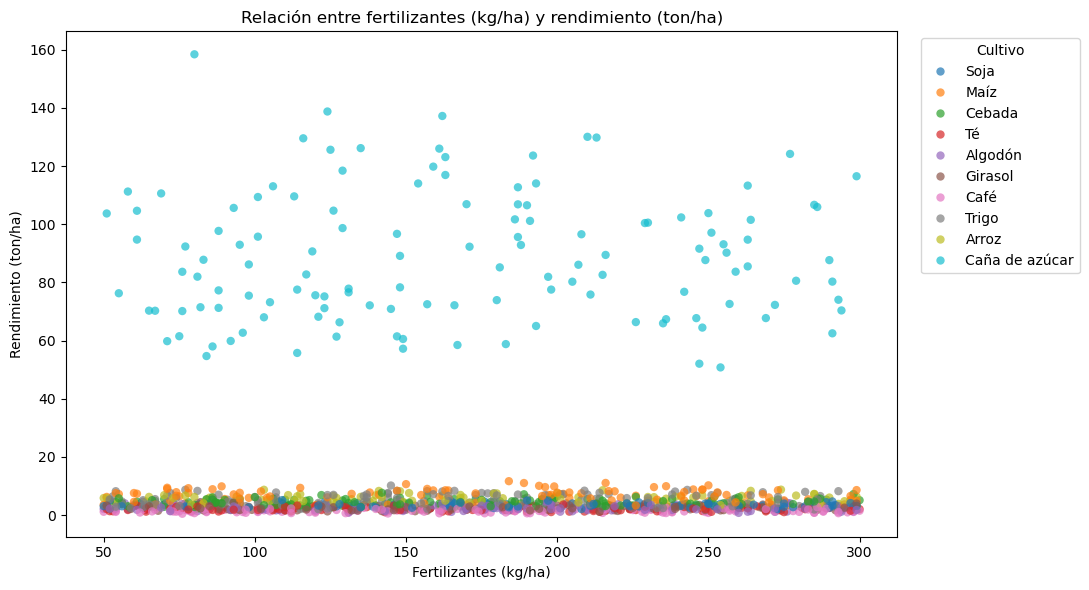

In [14]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=fertilizante_rendimiento,
    x='fertilizantes_kg_ha',
    y='rendimiento_ton_ha',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.title('Relación entre fertilizantes (kg/ha) y rendimiento (ton/ha)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Haciendo un análisis mas exhaustivo de la correlación que hay con cada cultivo, hemos visto que en realidad en el caso de la caña no hay un patrón claro con los estudios previos. Es decir, si bien su rendimiento es superior al resto de cultivos, su correlación con la cantidad de fertilizante y rendimiento es bastante baja por lo que no podemos afirmar que su "alto" rendimiento se deba a ello.

In [24]:
print('\nCorrelación por cultivo:')
for cultivo, grupo in fertilizante_rendimiento.groupby('cultivo'):
    corr = grupo['fertilizantes_kg_ha'].corr(grupo['rendimiento_ton_ha'])
    print(f'  {cultivo}: {corr:.2f}  (muestras={len(grupo)})')


Correlación por cultivo:
  Algodón: -0.09  (muestras=120)
  Arroz: -0.02  (muestras=90)
  Café: 0.09  (muestras=130)
  Caña de azúcar: 0.02  (muestras=130)
  Cebada: 0.12  (muestras=140)
  Girasol: 0.05  (muestras=120)
  Maíz: -0.07  (muestras=110)
  Soja: 0.01  (muestras=110)
  Trigo: -0.00  (muestras=140)
  Té: -0.04  (muestras=110)
